Libraries import

In [1]:
# import necessary
import os

# Set seed for reproducibility
SEED = 42

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np


# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph
from torchvision import datasets, transforms
from concurrent.futures import ThreadPoolExecutor

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO
from tqdm.notebook import tqdm
import zipfile
import glob
import math

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

# Check these
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

PyTorch version: 2.9.0+cu126
Device: cuda


Load data

In [2]:
from google.colab import drive
if not os.path.exists('/content/drive'):
    print("Connecting to Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive already connected.")

Connecting to Google Drive...
Mounted at /content/drive


In [3]:
#installing kaggle
!pip install --upgrade --force-reinstall --no-deps kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


In [4]:
COMPETITION_NAME = "an2dl2526c2v2"
DATASET_FOLDER = "dataset" #Folder where the data will be
KAGGLE_JSON_PATH_DRIVE = "/content/drive/MyDrive/2nd Challenge/kaggle.json"

In [5]:
#Note: with this approach to download data, every time we re run the code, the runtime must be cleaned!
#Check if data already downloaded
if(False):
    print(f"\n Data have been already downloaded in '{DATASET_FOLDER}'. Skip download.")

else:
    print("Let's start download...")
    # SETUP KAGGLE
    if os.path.exists(KAGGLE_JSON_PATH_DRIVE):
        print(f"Access to kaggle using these credentials: {KAGGLE_JSON_PATH_DRIVE}")

        !mkdir -p ~/.kaggle
        !cp "{KAGGLE_JSON_PATH_DRIVE}" ~/.kaggle/kaggle.json
        !chmod 600 ~/.kaggle/kaggle.json

        print("Granted access")

        # Test connection
        print("testing connection...")
        try:
            !kaggle competitions list | head -n 3
            print("Connection OK!")
        except:
            print("Impossible listing competitions, trying download.")

        # DOWNLOAD AND UNZIP
        print(f"\n Downloading challenge {COMPETITION_NAME}...")
        try:
            !kaggle competitions download -c {COMPETITION_NAME}

            zip_file = f"{COMPETITION_NAME}.zip"
            if os.path.exists(zip_file):
                print(f" Extracting in '{DATASET_FOLDER}'...")
                !mkdir -p {DATASET_FOLDER}
                !unzip -q {zip_file} -d {DATASET_FOLDER}
                os.remove(zip_file)
                print(f" Data ready in: {DATASET_FOLDER}")
            else:
                print("Error: Download failed (zip not found).")

        except Exception as e:
            print(f"Error during download: {e}")

    else:
        print(f"error: file kaggle.json not at {KAGGLE_JSON_PATH_DRIVE}")

Let's start download...
Access to kaggle using these credentials: /content/drive/MyDrive/2nd Challenge/kaggle.json
Granted access
testing connection...
ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd        800           False  
Connection OK!

 99% 929M/936M [00:09<00:00, 122MB/s]
100% 936M/936M [00:09<00:00, 104MB/s]
 Extracting in 'dataset'...
 Data ready in: dataset


In [6]:
BASE_DIR = 'dataset'

#source folders
SOURCE_TRAIN_DIR = os.path.join(BASE_DIR, 'train_data')
SOURCE_TEST_DIR = os.path.join(BASE_DIR, 'test_data')

#destination folders
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_images')
TRAIN_MASK_DIR = os.path.join(BASE_DIR, 'train_masks')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_images')
TEST_MASK_DIR = os.path.join(BASE_DIR, 'test_masks')

#creating destination folders if not existing
for d in [TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print("Starting data organization in folders...")

# managemente train data
if os.path.exists(SOURCE_TRAIN_DIR):
    print(f" found source folder: {SOURCE_TRAIN_DIR}")

    # collect images
    files = [f for f in os.listdir(SOURCE_TRAIN_DIR) if os.path.isfile(os.path.join(SOURCE_TRAIN_DIR, f))]

    if len(files) == 0:
        print("train_data folder is empty! Maybe images were already been moved?")
    else:
        print(f"Moving {len(files)} files...")

        for file in tqdm(files, desc="Train movement"):
            src_path = os.path.join(SOURCE_TRAIN_DIR, file)

            # Movement logic: we want to separate mask and images
            if file.startswith('img_'):
                shutil.move(src_path, os.path.join(TRAIN_IMG_DIR, file))
            elif file.startswith('mask_'):
                shutil.move(src_path, os.path.join(TRAIN_MASK_DIR, file))

        print("Training Data organized.")
else:
    print(f"Error: folder {SOURCE_TRAIN_DIR} not found")

# managing test data
if os.path.exists(SOURCE_TEST_DIR):
    print(f"found source folder:{SOURCE_TEST_DIR}")

    files = [f for f in os.listdir(SOURCE_TEST_DIR) if os.path.isfile(os.path.join(SOURCE_TEST_DIR, f))]

    if len(files) == 0:
        print("test_data folder is empty! Maybe images were already been moved?")
    else:
        print(f"Moving {len(files)} files...")

        for file in tqdm(files, desc="Test movement"):
            src_path = os.path.join(SOURCE_TEST_DIR, file)

            if file.startswith('img_'):
                shutil.move(src_path, os.path.join(TEST_IMG_DIR, file))
            elif file.startswith('mask_'):
                shutil.move(src_path, os.path.join(TEST_MASK_DIR, file))

        print("Test Data organized.")
else:
    print(f"Error: folder {SOURCE_TRAIN_DIR} not found")

# verifying if also labels are in right place
path_labels = os.path.join(BASE_DIR, 'train_labels.csv')
if os.path.exists(path_labels):
    print(f"labels file found: {path_labels}")
else:
    print("labels file not found in dataset root.")

print("\n Operation completed!")

Starting data organization in folders...
 found source folder: dataset/train_data
Moving 1382 files...


Train movement:   0%|          | 0/1382 [00:00<?, ?it/s]

Training Data organized.
found source folder:dataset/test_data
Moving 954 files...


Test movement:   0%|          | 0/954 [00:00<?, ?it/s]

Test Data organized.
labels file found: dataset/train_labels.csv

 Operation completed!


Data exploration

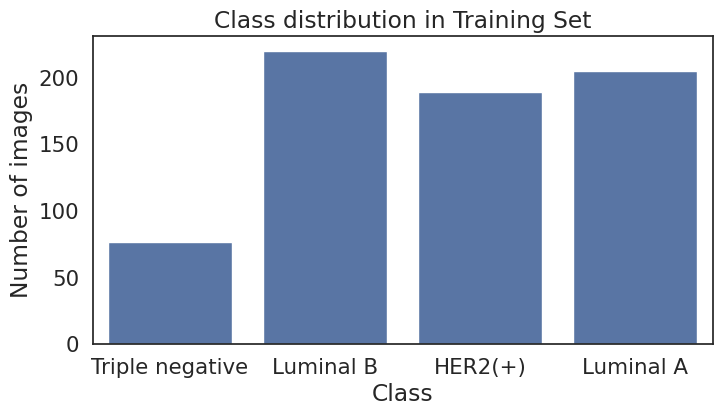


Number of images in each class:
Class Triple negative: 77 images
Class Luminal B: 220 images
Class HER2(+): 189 images
Class Luminal A: 205 images


In [7]:
#let's visualise classes distribution
df_labels = pd.read_csv(os.path.join(BASE_DIR, 'train_labels.csv'))
df_labels['sample_index'] = df_labels['sample_index'].astype(str)

plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df_labels)
plt.title("Class distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

print('\nNumber of images in each class:')

for label in df_labels['label'].unique():
    label_count = df_labels[df_labels['label'] == label].shape[0]
    print(f"Class {label}: {label_count} images")

As we can see our train dataset is slighlty imbalanced, in particular we have fewer samples from Class 'Triple negative', we will consider this both when we will train our model and when we will do data augmentation.

### Visualize Sample Image-Mask Pairs

Let's visualize a few original images alongside their corresponding masks to understand the dataset structure and mask quality.

In [8]:
#let's search for images containing above the 10% of green
# --- CONFIGURATION ---
input_img_dir = TRAIN_IMG_DIR
THRESHOLD_FORBIDDEN = 0.10    # 10% of tolerance

# Founding
img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
forbidden_images = [] # (path, score)

print(f"Scanning {len(img_paths)} images...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # forbidden range  (as above)
    lower_forbidden = np.array([25, 40, 40])
    upper_forbidden = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower_forbidden, upper_forbidden)

    ratio = cv2.countNonZero(mask) / (img.shape[0] * img.shape[1])

    if ratio > THRESHOLD_FORBIDDEN:
        forbidden_images.append((img_path, ratio))

# Sorting: greenest at first
forbidden_images.sort(key=lambda x: x[1], reverse=True)
num_bad = len(forbidden_images)

print(f"found {num_bad} intruses.")

'''# Showing
if num_bad > 0:
    # Grid configuration
    cols = 4  # 4 images par row
    rows = math.ceil(num_bad / cols) # check how many rows are needed

    # image dimensioning
    plt.figure(figsize=(20, 5 * rows))

    for i, (path, score) in enumerate(forbidden_images):
        # load and convert images
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Creating subplot
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        # Title with filename and percentage of "forbidden color"
        filename = os.path.basename(path)
        plt.title(f"{filename}\nGreen/Yellow: {score*100:.2f}%", fontsize=12, color='red', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No forbidden image found!")'''


Scanning 691 images...
found 14 intruses.


'# Showing\nif num_bad > 0:\n    # Grid configuration\n    cols = 4  # 4 images par row\n    rows = math.ceil(num_bad / cols) # check how many rows are needed\n\n    # image dimensioning\n    plt.figure(figsize=(20, 5 * rows))\n\n    for i, (path, score) in enumerate(forbidden_images):\n        # load and convert images\n        img = cv2.imread(path)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n        # Creating subplot\n        ax = plt.subplot(rows, cols, i + 1)\n        plt.imshow(img)\n\n        # Title with filename and percentage of "forbidden color"\n        filename = os.path.basename(path)\n        plt.title(f"{filename}\nGreen/Yellow: {score*100:.2f}%", fontsize=12, color=\'red\', fontweight=\'bold\')\n        plt.axis(\'off\')\n\n    plt.tight_layout()\n    plt.show()\nelse:\n    print("No forbidden image found!")'

In [9]:
#we found 41 images, and we see all of them are shreck ones; we append their path to a list
shreck_paths = []
schreck_count = 0
for path in forbidden_images:
  schreck_count += 1
  shreck_paths.append(path[0])
  print(f"{path[0]} has been appended")

dataset/train_images/img_0189.png has been appended
dataset/train_images/img_0390.png has been appended
dataset/train_images/img_0558.png has been appended
dataset/train_images/img_0319.png has been appended
dataset/train_images/img_0572.png has been appended
dataset/train_images/img_0022.png has been appended
dataset/train_images/img_0521.png has been appended
dataset/train_images/img_0540.png has been appended
dataset/train_images/img_0499.png has been appended
dataset/train_images/img_0609.png has been appended
dataset/train_images/img_0085.png has been appended
dataset/train_images/img_0159.png has been appended
dataset/train_images/img_0138.png has been appended
dataset/train_images/img_0180.png has been appended


In [10]:
#now, let's check for images below 10% of green, containing a bit of green and less than 10% of pink;
#in this way, we are trying to not have the correct images shown

# CONFIGURATION
input_img_dir = TRAIN_IMG_DIR

# FILTER 1: Some green somewhere
THRESHOLD_FORBIDDEN = 0.01    # Se c'è più del 10% di verde, l'immagine è SOSPETTA

# FILTER 2: to save the tissue, search for pink!
# If the image has more than 15% of tissue pink/purple, we save it even if it contains some green!
THRESHOLD_PINK_SAFE = 0.10

# Founding
img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
forbidden_images_2 = [] # (path, green_score, pink_score)

print(f"Scanning {len(img_paths)} images using filters...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    total_pixels = img.shape[0] * img.shape[1]

    # STEP 1: GREEN
    lower_forbidden = np.array([25, 40, 40])
    upper_forbidden = np.array([95, 255, 255])
    mask_green = cv2.inRange(hsv, lower_forbidden, upper_forbidden)
    green_ratio = cv2.countNonZero(mask_green) / total_pixels

    # If amount of green below threshold, valid image! skip it
    if green_ratio <= THRESHOLD_FORBIDDEN:
        continue

    # STEP 2: PINK
    # If we are here, the image has more than 1% of green. But, it can be a dirty slide!
    # We search for the tissue!

    # Range Purple/Pink(Cores)
    lower_tissue1 = np.array([130, 30, 30])
    upper_tissue1 = np.array([180, 255, 255])

    # Range Red/Orange (Cytoplasm)
    lower_tissue2 = np.array([0, 30, 30])
    upper_tissue2 = np.array([20, 255, 255])

    mask_pink1 = cv2.inRange(hsv, lower_tissue1, upper_tissue1)
    mask_pink2 = cv2.inRange(hsv, lower_tissue2, upper_tissue2)
    mask_tissue = cv2.bitwise_or(mask_pink1, mask_pink2)

    pink_ratio = cv2.countNonZero(mask_tissue) / total_pixels

    # final judgement:
    # image is a noise if:
    # 1. more than 1% of green (green_ratio > THRESHOLD_FORBIDDEN)
    # 2. it has few tissues pixels (pink_ratio < THRESHOLD_PINK_SAFE)

    if pink_ratio < THRESHOLD_PINK_SAFE:
        # Lot of green, no tissue: probably a noise!
        forbidden_images_2.append((img_path, green_ratio, pink_ratio))
    else:
        # Is a dirty slide! Keep it!
        pass

# Sorting by green (high) and pink (low)
forbidden_images_2.sort(key=lambda x: x[1], reverse=True)
num_bad = len(forbidden_images_2)

print(f"After filtering, founded {num_bad} intruses.")

'''# Showing
if num_bad > 0:
    cols = 4
    rows = math.ceil(num_bad / cols)

    plt.figure(figsize=(20, 5 * rows))

    for i, (path, g_score, p_score) in enumerate(forbidden_images_2):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        filename = os.path.basename(path)
        plt.title(f"{filename}\nGreen: {g_score*100:.1f}% | Pink: {p_score*100:.1f}%",
                  fontsize=11, color='red', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No forbidden image found!")'''

Scanning 691 images using filters...
After filtering, founded 68 intruses.


'# Showing\nif num_bad > 0:\n    cols = 4\n    rows = math.ceil(num_bad / cols)\n\n    plt.figure(figsize=(20, 5 * rows))\n\n    for i, (path, g_score, p_score) in enumerate(forbidden_images_2):\n        img = cv2.imread(path)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n        ax = plt.subplot(rows, cols, i + 1)\n        plt.imshow(img)\n\n        filename = os.path.basename(path)\n        plt.title(f"{filename}\nGreen: {g_score*100:.1f}% | Pink: {p_score*100:.1f}%",\n                  fontsize=11, color=\'red\', fontweight=\'bold\')\n        plt.axis(\'off\')\n\n    plt.tight_layout()\n    plt.show()\nelse:\n    print("No forbidden image found!")'

from this showing, we note that all the green noises which are not shreck corresponds to a concentration of green equal to the 4.6% of the total; so, we will remove all the images which are in forbidden_images_2 with a green concentration different from 4.6%

In [11]:
skifidol_paths = []
new_schreck_count = 0
skifidol_count = 0
for path in forbidden_images_2:
  if path[1] > 0.047:
    if path[0] not in shreck_paths:
      new_schreck_count += 1
      shreck_paths.append(path[0])
  else:
    skifidol_count += 1
    skifidol_paths.append(path[0])
print(f"skifidol: {skifidol_count}")
print(f"new schreck: {new_schreck_count}")
print(f"total schrecks:{new_schreck_count+schreck_count}")
print(len(shreck_paths))
print(len(skifidol_paths))

skifidol: 39
new schreck: 15
total schrecks:29
29
39


In [12]:
#now, we will focus on the images with more than 1% of green and more than 10% of pink;
#maybe some shrecks are containing pink grades :
#now, let's check for images below 10% of green, containing a bit of green and less than 10% of pink;
#in this way, we are trying to not have the correct images shown


# CONFIGURATION
input_img_dir = TRAIN_IMG_DIR

# FILTER 1: Green
THRESHOLD_FORBIDDEN = 0.01

# FILTER 2: Pink
THRESHOLD_PINK_SAFE = 0.10

# Founding
img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
forbidden_images_3 = [] # (path, green_score, pink_score)

print(f"Scanning {len(img_paths)} images with filters...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    total_pixels = img.shape[0] * img.shape[1]

    # Step1: GREEN
    lower_forbidden = np.array([25, 40, 40])
    upper_forbidden = np.array([95, 255, 255])
    mask_green = cv2.inRange(hsv, lower_forbidden, upper_forbidden)
    green_ratio = cv2.countNonZero(mask_green) / total_pixels

    # If less than 1% of green is a valid image! Keep it
    if green_ratio <= THRESHOLD_FORBIDDEN:
        continue

    # Step2: pink
    # Same as previous cells
    lower_tissue1 = np.array([130, 30, 30])
    upper_tissue1 = np.array([180, 255, 255])

    lower_tissue2 = np.array([0, 30, 30])
    upper_tissue2 = np.array([20, 255, 255])

    mask_pink1 = cv2.inRange(hsv, lower_tissue1, upper_tissue1)
    mask_pink2 = cv2.inRange(hsv, lower_tissue2, upper_tissue2)
    mask_tissue = cv2.bitwise_or(mask_pink1, mask_pink2)

    pink_ratio = cv2.countNonZero(mask_tissue) / total_pixels

    # FINAL JUDGEMENT
    # We are searching for images with lot of green and also pink (blob images)
    if pink_ratio >= THRESHOLD_PINK_SAFE:
        #possible blob! check it
        forbidden_images_3.append((img_path, green_ratio, pink_ratio))
    else:
        pass

# Sorting
forbidden_images_3.sort(key=lambda x: x[1], reverse=True)
num_bad = len(forbidden_images_3)

print(f"After filtering, {num_bad} intruses found.")

'''# Showing
if num_bad > 0:
    cols = 4
    rows = math.ceil(num_bad / cols)

    plt.figure(figsize=(20, 5 * rows))

    for i, (path, g_score, p_score) in enumerate(forbidden_images_3):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        filename = os.path.basename(path)
        plt.title(f"{filename}\nGreen: {g_score*100:.1f}% | Pink: {p_score*100:.1f}%",
                  fontsize=11, color='red', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No noisy images founded!")'''

Scanning 691 images with filters...
After filtering, 12 intruses found.


'# Showing\nif num_bad > 0:\n    cols = 4\n    rows = math.ceil(num_bad / cols)\n\n    plt.figure(figsize=(20, 5 * rows))\n\n    for i, (path, g_score, p_score) in enumerate(forbidden_images_3):\n        img = cv2.imread(path)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n        ax = plt.subplot(rows, cols, i + 1)\n        plt.imshow(img)\n\n        filename = os.path.basename(path)\n        plt.title(f"{filename}\nGreen: {g_score*100:.1f}% | Pink: {p_score*100:.1f}%",\n                  fontsize=11, color=\'red\', fontweight=\'bold\')\n        plt.axis(\'off\')\n\n    plt.tight_layout()\n    plt.show()\nelse:\n    print("No noisy images founded!")'

We note 5 more shrecks and lots of noised images; we split again the images; another thing is that not all the images are corrupted: somee of them are still good to use! we must pay attention to not discard them!

In [13]:
new_schreck_count = 0
new_skifidol_count = 0
not_noisy_img = []
for path in forbidden_images_3:
  if path[1] > 0.14:
    if path[0] not in shreck_paths:
      new_schreck_count += 1
      shreck_paths.append(path[0])
  elif path[1] < 0.047 and path[1] > 0.02:
    if path[0] not in skifidol_paths:
      new_skifidol_count += 1
      skifidol_paths.append(path[0])
  else:
    print(f"not appended {path[0]}")
    not_noisy_img.append(path[0])
print(f"newfrecks: {new_schreck_count}")
print(f"total schrecks:{len(shreck_paths)}")
print(f"newskifidol: {new_skifidol_count}")
print(f"total skifidol:{len(skifidol_paths)}")
print(f"not noisy: {len(not_noisy_img)}")

newfrecks: 0
total schrecks:29
newskifidol: 12
total skifidol:51
not noisy: 0


In [14]:
# CONFIGURATION
input_img_dir = TRAIN_IMG_DIR

# Green thresholds reduced
TARGET_GREEN_MIN = 0.001  # 0.5%
TARGET_GREEN_MAX = 0.01   # 1.0%

# NOTE: No THRESHOLD_PINK:
# We want to see only this green range.

# Founding
img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
target_images = [] # (path, green_score, pink_score)

print(f"Scanning {len(img_paths)} images. Searching green in range: 0.5% < Green < 1%...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    total_pixels = img.shape[0] * img.shape[1]

    # Step 1: Green
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([95, 255, 255])
    mask_green = cv2.inRange(hsv, lower_green, upper_green)
    green_ratio = cv2.countNonZero(mask_green) / total_pixels

    if not (TARGET_GREEN_MIN < green_ratio):
        continue  # if not in range, go ahead

    # Step 2: pink (only for information) ---
    lower_tissue1 = np.array([130, 30, 30])
    upper_tissue1 = np.array([180, 255, 255])
    lower_tissue2 = np.array([0, 30, 30])
    upper_tissue2 = np.array([20, 255, 255])
    mask_tissue = cv2.bitwise_or(cv2.inRange(hsv, lower_tissue1, upper_tissue1),
                                 cv2.inRange(hsv, lower_tissue2, upper_tissue2))

    pink_ratio = cv2.countNonZero(mask_tissue) / total_pixels

    # appen everything in that green range
    target_images.append((img_path, green_ratio, pink_ratio))

# Sorting
target_images.sort(key=lambda x: x[1], reverse=True)
num_found = len(target_images)

print(f"Trovate {num_found} immagini con verde tra 0.5% e 1%.")

'''# Showing
if num_found > 0:
    cols = 4
    rows = math.ceil(num_found / cols)

    # Limit
    if rows > 20:
        print(f" Showing only the first 40 of {num_found}.")
        target_images = target_images[:40]
        num_found = 40
        rows = 10

    plt.figure(figsize=(20, 5 * rows))

    for i, (path, g_score, p_score) in enumerate(target_images):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        filename = os.path.basename(path)'''

Scanning 691 images. Searching green in range: 0.5% < Green < 1%...
Trovate 80 immagini con verde tra 0.5% e 1%.


'# Showing\nif num_found > 0:\n    cols = 4\n    rows = math.ceil(num_found / cols)\n\n    # Limit\n    if rows > 20:\n        print(f" Showing only the first 40 of {num_found}.")\n        target_images = target_images[:40]\n        num_found = 40\n        rows = 10\n\n    plt.figure(figsize=(20, 5 * rows))\n\n    for i, (path, g_score, p_score) in enumerate(target_images):\n        img = cv2.imread(path)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n        ax = plt.subplot(rows, cols, i + 1)\n        plt.imshow(img)\n\n        filename = os.path.basename(path)'

In [15]:
potential_new_errors = []
for path in target_images:
  if path[0] not in shreck_paths and path[0] not in skifidol_paths and path[0] not in not_noisy_img:
    potential_new_errors.append(path[0])
print(len(potential_new_errors))

0


In [16]:
print(f"total schrecks:{len(shreck_paths)}")
print(f"total skifidol:{len(skifidol_paths)}")
print(f"not noisy: {len(not_noisy_img)}")

total schrecks:29
total skifidol:51
not noisy: 0


In [17]:
#let's now search for yellows images

# CONFIGURATION ---
input_img_dir = TRAIN_IMG_DIR
THRESHOLD_YELLOW = 0.10        # Searching images with more than 10% yellow

# Yellow founding
img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
yellow_images = [] # (path, score)

print(f"Scanning {len(img_paths)} images searching for yellow (> 10%)...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    total_pixels = img.shape[0] * img.shape[1]

    # Yellow defininitio
    # In OpenCV l'Hue goes from 0 to 180.
    # 0-15 is red or orange
    # 15-35: YELLOW (Target)
    # 35-85 is Green

    lower_yellow = np.array([15, 40, 40])
    upper_yellow = np.array([35, 255, 255])

    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    ratio = cv2.countNonZero(mask) / total_pixels

    if ratio > THRESHOLD_YELLOW:
        yellow_images.append((img_path, ratio))

# Sorting: the most yellow at the top
yellow_images.sort(key=lambda x: x[1], reverse=True)
num_yellow = len(yellow_images)

print(f"Found {num_yellow} images above yellow threshold.")

'''# Showing
if num_yellow > 0:
    cols = 4
    rows = math.ceil(num_yellow / cols)

    # Limit
    if rows > 20:
        print("Showing only the first 40 images.")
        yellow_images = yellow_images[:40]
        rows = 10
        num_yellow = 40

    plt.figure(figsize=(20, 5 * rows))

    for i, (path, score) in enumerate(yellow_images):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        filename = os.path.basename(path)
        plt.title(f"{filename}\nYellow: {score*100:.2f}%", fontsize=12, color='orange', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No too yellow images found.")'''

Scanning 691 images searching for yellow (> 10%)...
Found 30 images above yellow threshold.


'# Showing\nif num_yellow > 0:\n    cols = 4\n    rows = math.ceil(num_yellow / cols)\n\n    # Limit\n    if rows > 20:\n        print("Showing only the first 40 images.")\n        yellow_images = yellow_images[:40]\n        rows = 10\n        num_yellow = 40\n\n    plt.figure(figsize=(20, 5 * rows))\n\n    for i, (path, score) in enumerate(yellow_images):\n        img = cv2.imread(path)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n        ax = plt.subplot(rows, cols, i + 1)\n        plt.imshow(img)\n\n        filename = os.path.basename(path)\n        plt.title(f"{filename}\nYellow: {score*100:.2f}%", fontsize=12, color=\'orange\', fontweight=\'bold\')\n        plt.axis(\'off\')\n\n    plt.tight_layout()\n    plt.show()\nelse:\n    print("No too yellow images found.")'

In [18]:
new_schreck_count = 0
for path in yellow_images:
  if path[0] not in shreck_paths:
    new_schreck_count += 1
    shreck_paths.append(path[0])
print(f"newfrecks: {new_schreck_count}")
print(f"totalfrecks: {len(shreck_paths)}")

newfrecks: 13
totalfrecks: 42


Scanning 691 images searching for yellow (> 1%)...
Found 30 images above new threshold.


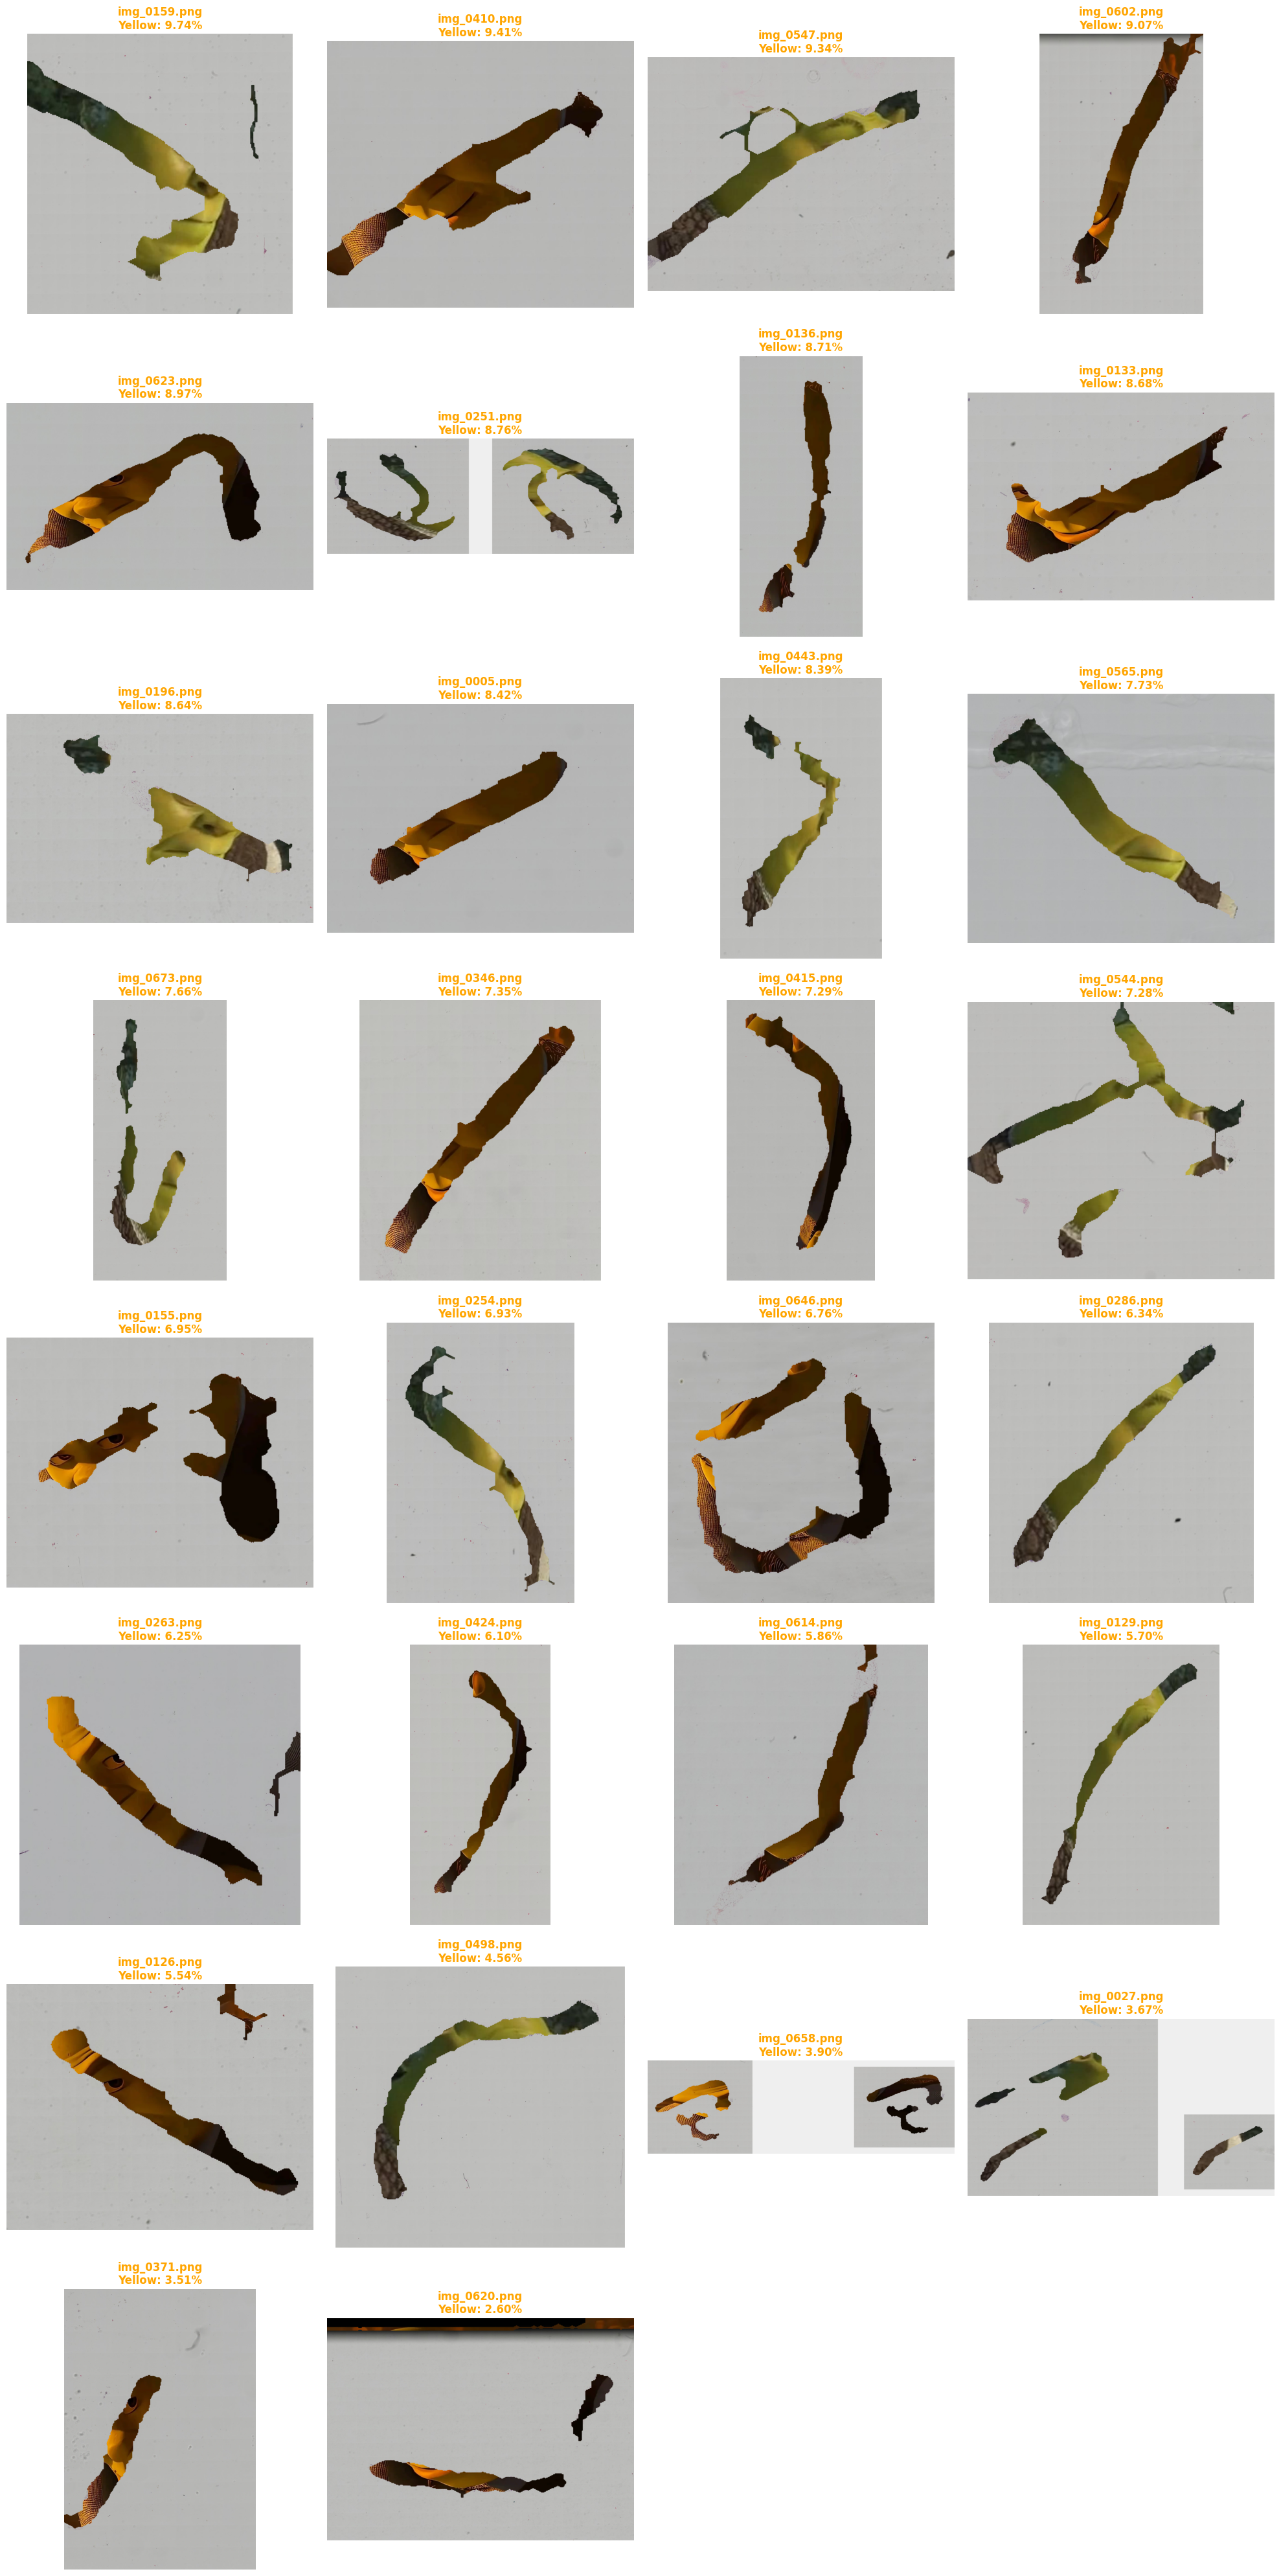

In [19]:
#let's now search for yellows images reducing the threshold: is the same code as above, but reducing the threshold.

input_img_dir = TRAIN_IMG_DIR
THRESHOLD_YELLOW = 0.01        # threshold reduced to 1%

img_paths = glob.glob(os.path.join(input_img_dir, "*.png"))
yellow_images_2 = [] # (path, score)

print(f"Scanning {len(img_paths)} images searching for yellow (> 1%)...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    total_pixels = img.shape[0] * img.shape[1]


    lower_yellow = np.array([15, 40, 40])
    upper_yellow = np.array([35, 255, 255])

    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    ratio = cv2.countNonZero(mask) / total_pixels

    if ratio >= THRESHOLD_YELLOW and ratio < 0.1:
        yellow_images_2.append((img_path, ratio))

yellow_images_2.sort(key=lambda x: x[1], reverse=True)

# Correctly calculate num_yellow based on the populated yellow_images_2
num_yellow = len(yellow_images_2)

print(f"Found {num_yellow} images above new threshold.")

if num_yellow > 0:
    cols = 4
    rows = math.ceil(num_yellow / cols)

    # Limit
    if rows > 20:
        print("Showing only first 40 images")
        yellow_images_2 = yellow_images_2[:40] # Slice the list before calculating num_yellow and rows again
        num_yellow = len(yellow_images_2)
        rows = math.ceil(num_yellow / cols) # Recalculate rows after slicing

    plt.figure(figsize=(20, 5 * rows))

    for i, (path, score) in enumerate(yellow_images_2):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        filename = os.path.basename(path)
        plt.title(f"{filename}\nYellow: {score*100:.2f}%", fontsize=12, color='orange', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No too yellow images found.")

In [20]:
new_yellow_count = 0
for path in yellow_images_2:
  if path[0] not in shreck_paths:
    new_yellow_count += 1
    shreck_paths.append(path[0])
print(f"newyellowschrecks: {new_yellow_count}")
print(f"totalschrecks: {len(shreck_paths)}")

newyellowschrecks: 18
totalschrecks: 60


In [21]:
shreck_paths.sort()
skifidol_paths.sort()

In [22]:
'''# Computing grid dimensions
num_images = len(shreck_paths)
cols = 4
rows = math.ceil(num_images / cols)

# Dynamic dimensioning of the images
plt.figure(figsize=(20, 5 * rows))

for i, path in enumerate(shreck_paths):
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    filename = os.path.basename(path)
    plt.title(f"{filename}", fontsize=9, color='orange', fontweight='bold', pad=3)
    plt.axis('off')

plt.tight_layout()
plt.show()'''

'# Computing grid dimensions\nnum_images = len(shreck_paths)\ncols = 4\nrows = math.ceil(num_images / cols)\n\n# Dynamic dimensioning of the images\nplt.figure(figsize=(20, 5 * rows))\n\nfor i, path in enumerate(shreck_paths):\n    img = cv2.imread(path)\n\n    if img is None:\n        continue\n\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    ax = plt.subplot(rows, cols, i + 1)\n    plt.imshow(img)\n\n    filename = os.path.basename(path)\n    plt.title(f"{filename}", fontsize=9, color=\'orange\', fontweight=\'bold\', pad=3)\n    plt.axis(\'off\')\n\nplt.tight_layout()\nplt.show()'

In [23]:
'''#  Computing grid dimensions
num_images = len(skifidol_paths)
cols = 4
rows = math.ceil(num_images / cols)

#  Dynamic dimensioning of the images
plt.figure(figsize=(20, 5 * rows))

for i, path in enumerate(skifidol_paths):
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    filename = os.path.basename(path)
    plt.title(f"{filename}", fontsize=9, color='orange', fontweight='bold', pad=3)
    plt.axis('off')

plt.tight_layout()
plt.show()'''

'#  Computing grid dimensions\nnum_images = len(skifidol_paths)\ncols = 4\nrows = math.ceil(num_images / cols)\n\n#  Dynamic dimensioning of the images\nplt.figure(figsize=(20, 5 * rows))\n\nfor i, path in enumerate(skifidol_paths):\n    img = cv2.imread(path)\n\n    if img is None:\n        continue\n\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    ax = plt.subplot(rows, cols, i + 1)\n    plt.imshow(img)\n\n    filename = os.path.basename(path)\n    plt.title(f"{filename}", fontsize=9, color=\'orange\', fontweight=\'bold\', pad=3)\n    plt.axis(\'off\')\n\nplt.tight_layout()\nplt.show()'

In [24]:
#we note that img_027 has been wrongly placed also in skifidol_paths, so we remove it
skifidol_paths.remove(skifidol_paths[4])
print(len(skifidol_paths))

50


In [25]:
'''# show again to check if it was correctly removed
# Computing grid dimensions
num_images = len(skifidol_paths)
cols = 4
rows = math.ceil(num_images / cols)

#  Dynamic dimensioning of the images
plt.figure(figsize=(20, 5 * rows))

for i, path in enumerate(skifidol_paths):
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    filename = os.path.basename(path)
    plt.title(f"{filename}", fontsize=9, color='orange', fontweight='bold', pad=3)
    plt.axis('off')

plt.tight_layout()
plt.show() '''

'# show again to check if it was correctly removed\n# Computing grid dimensions\nnum_images = len(skifidol_paths)\ncols = 4\nrows = math.ceil(num_images / cols)\n\n#  Dynamic dimensioning of the images\nplt.figure(figsize=(20, 5 * rows))\n\nfor i, path in enumerate(skifidol_paths):\n    img = cv2.imread(path)\n\n    if img is None:\n        continue\n\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    ax = plt.subplot(rows, cols, i + 1)\n    plt.imshow(img)\n\n    filename = os.path.basename(path)\n    plt.title(f"{filename}", fontsize=9, color=\'orange\', fontweight=\'bold\', pad=3)\n    plt.axis(\'off\')\n\nplt.tight_layout()\nplt.show() '

Now that we have found using these filters all the 'noisy' images, we generate some txt files containing the paths of the not usable training images. In this way, we can use these files in other notebooks to clean easily our training set

In [26]:
# Choose output filename
output_filename = "new_dataset_final_list_shrek_images.txt"
# File writing
with open(output_filename, "w") as f:
    for path in shreck_paths:
        f.write(f"{path}\n")  # Write the path and go down

print(f"File '{output_filename}' created successfully! ({len(shreck_paths)} rows).")

# File download
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    print(f"You are not in Google Colab: file saved locally as '{output_filename}'.")

File 'new_dataset_final_list_shrek_images.txt' created successfully! (60 rows).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Choose output filename
output_filename = "new_dataset_final_sorted_skifidol_paths.txt"
# File writing
with open(output_filename, "w") as f:
    for path in skifidol_paths:
        f.write(f"{path}\n")   # Write the path and go down

print(f"File '{output_filename}' created successfully! ({len(skifidol_paths)} rows).")

# File download
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
     print(f"You are not in Google Colab: file saved locally as '{output_filename}'.")

File 'new_dataset_final_sorted_skifidol_paths.txt' created successfully! (50 rows).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
#we generate the txt containing the masks of the shreck images
# Choose output filename
output_filename = "new_dataset_mask_shrek_images.txt"
# File writing
with open(output_filename, "w") as f:
    for path in shreck_paths:
        mask_path = path.replace("img", "mask")
        mask_path = mask_path.replace("images", "masks")
        f.write(f"{mask_path}\n")   # Write the path and go down
print(f"File '{output_filename}' created successfully! ({len(shreck_paths)} rows).")

# File download
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
     print(f"You are not in Google Colab: file saved locally as '{output_filename}'.")

File 'new_dataset_mask_shrek_images.txt' created successfully! (60 rows).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Choose output filename
output_filename = "new_dataset_masks_skifidol_paths.txt"
# File writing
with open(output_filename, "w") as f:
    for path in skifidol_paths:
        mask_path = path.replace("img", "mask")
        mask_path = mask_path.replace("images", "masks")
        f.write(f"{mask_path}\n")  # Write the path and go down

print(f"File '{output_filename}' created successfully! ({len(skifidol_paths)} rows).")


# File download
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    print(f"You are not in Google Colab: file saved locally as '{output_filename}'.")

File 'new_dataset_masks_skifidol_paths.txt' created successfully! (50 rows).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This was the notebook we used to find what images were noisy. The training is done in other notebooks, cleaning the dataset using the txt we generated here!